# Predicting drug clearance under latent genetic heterogeneity


This notebook investigates Kernel Gradient Discrepancy (KGD) as a convergence diagnostic and stopping criterion for Wasserstein Gradient Flow (WGF) in Predictive Optimisation (PrO) applied to a clinical pharmacology example.

KGD measures the pairwise alignment of the residual WGF vector field across particles, with nearby particles contributing more strongly (usually) through the kernel weighting.

The Wasserstein gradient of the entropy-regularised objective $J(Q) = \lambda_n \frac{1}{n} \sum_{i=1}^{n} S(P_Q, x_i) + D_{\text{KL}}(Q \parallel Q_0)$ defines the velocity field:

$$\nabla_{\vartheta} \mathcal{J}(Q)(\vartheta) = \underbrace{\frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right)}_{\text{Predictive Data-fit Gradient}} + \underbrace{ \nabla_\vartheta\log q(\vartheta) - \nabla_\vartheta\log\pi(\vartheta) }_{\text{KL Divergence Gradient}}$$

If the swarm has reached the optimal equilibrium, this gradient should be zero everywhere. However, because we are using discrete particles, the continuous density $q$ is unknown, making the entropy term $\nabla_\vartheta \log q(\vartheta)$ impossible to compute directly.

Because we cannot compute the true gradient directly, we measure it indirectly. We introduce an arbitrary smooth "test" vector field $f(\vartheta)$ from a Reproducing Kernel Hilbert Space (RKHS) and measure how strongly our true gradient aligns with it. By taking the expected alignment over our distribution $Q$, we can rely on Stein’s Identity. Assuming the density $q$ vanishes at the boundaries of the domain, we can use integration by parts to shift the spatial derivative off of the intractable density and onto our chosen test field $f$:

Let $\frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right) =\nabla_{\vartheta} \mathcal{L}(Q)(\vartheta)$.

$$\int \nabla_{\vartheta} \mathcal{J}(Q)(\vartheta) \cdot f(\vartheta) \, dQ(\vartheta)$$
$$= \int \left[ \nabla_{\vartheta} \mathcal{L}(Q)(\vartheta) - (\nabla \log \pi)(\vartheta)  \right]\cdot f(\vartheta) dQ(\vartheta) + \int \left( \nabla \log q \right)(\vartheta) \cdot f(\vartheta) \, dQ(\vartheta)$$
$$= \int \left[ \nabla_{\vartheta} \mathcal{L}(Q)(\vartheta) - (\nabla \log \pi)(\vartheta) \right]\cdot f(\vartheta) dQ(\vartheta) - \int (\nabla \cdot f)(\vartheta) dQ(\vartheta)$$
$$= - \int \mathcal{T}_{Q} f(\vartheta) \, dQ(\vartheta).$$

By grouping this resulting negative divergence term with the deterministic drift terms from the loss and prior, we arrive exactly at the definition of the negative Variational Stein Operator, $-T_Q f(\vartheta)$. This mathematical maneuver is the entire reason Kernel Gradient Discrepancy is computable without knowing the continuous density of the particle swarm.

This transformation is formalized by the Variational Stein Operator ($\mathcal{T}_Q$). For an arbitrary RKHS vector field $f(\vartheta)$:

$$\mathcal{T}_{Q, \vartheta} f(\vartheta) = \nabla_\vartheta \cdot f(\vartheta) - f(\vartheta)^T b(\vartheta, Q)$$

Notice that the operator evaluates the vector field entirely using the known drift $b(\vartheta, Q) = \frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right) - \nabla_\vartheta\log\pi(\vartheta)$ and the spatial divergence $\nabla_\vartheta \cdot f(\vartheta)$, completely eliminating $\log q$ from the computation.

KGD is formally defined by finding the "worst-case" test field $f$ in the RKHS unit ball that maximizes this computable alignment (a Stein discrepancy):

$$\mathrm{KGD}_{\mathcal K}(Q) = \sup_{\substack{f\in\mathcal B_{\mathcal K}\\\mathcal T_Q f\in L^1(Q)}}\left\vert{}\int \mathcal T_Q f(\vartheta)\,dQ(\vartheta)\right\vert{}.$$

By the Riesz representation theorem, this operator has a unique representer in the RKHS, which we will call $v_Q$ (the projected Wasserstein gradient). The supremum is maximized when the test field $f$ points in the exact direction of $v_Q$. Therefore, the supremum is perfectly solved and reduces KGD to the norm of this projected vector field:

$$\mathrm{KGD}(Q)=\vert{}\vert{}v_Q\vert{}\vert{}_{\mathcal H_K}.$$

We can express this squared norm as a double expectation over the distribution $Q$:

$$\mathrm{KGD}^2(Q)=\iint v_Q(\vartheta)^TK(\vartheta,\vartheta')v_Q(\vartheta')\,dQ(\vartheta)dQ(\vartheta').$$


To compute this without explicitly constructing $v_Q$, we apply the Variational Stein operator to our kernel twice which creates the Stein Kernel, $h_Q(\vartheta, \vartheta')$:
$$h_Q(\vartheta, \vartheta') = \mathcal{T}_{Q, \vartheta} \mathcal{T}_{Q, \vartheta'} K(\vartheta, \vartheta')$$

Applying these operators to our kernel results in:

$$h_Q(\vartheta, \vartheta') = b_Q(\vartheta)^T K(\vartheta, \vartheta') b_Q(\vartheta') - b_Q(\vartheta)^T \nabla_{\vartheta'} K(\vartheta, \vartheta') - \nabla_\vartheta K(\vartheta, \vartheta')^T b_Q(\vartheta') + \mathrm{Tr}\big( \nabla_\vartheta \nabla_{\vartheta'} K(\vartheta, \vartheta') \big)$$

Transitioning from the continuous distribution $Q$ to our empirical particle swarm $Q_n$, the double expectation integral becomes a double summation over all $N_p$ pairwise particle interactions. This yields the exact, fully computable equation utilized in our implementation:

$$\mathrm{KGD}^2(Q_n) = \frac{1}{N_p^2} \sum_{j=1}^{N_p} \sum_{l=1}^{N_p} h_{Q_n}(\vartheta^{(j)}, \vartheta^{(l)})$$



### Setup

In clinical pharmacology, a central problem is predicting how quickly a patient eliminates a drug from their body (their clearance, $\mathrm{CL}$). Clearance is typically modeled on the log scale, $y = \log(\mathrm{CL})$, where physiological covariates like body weight and age act multiplicatively.

In this study, the drug is metabolized by an enzyme called NAT2. In human populations, genetic variation creates three distinct metabolic sub-populations with very different baseline clearance rates:
* Slow metabolizers (56% of patients, baseline clearance 17.7 L/h)
* Intermediate metabolizers (33% of patients, baseline clearance 37.8 L/h)
* Rapid metabolizers (11% of patients, baseline clearance 55.9 L/h)

Individual clearance also scales with body weight via standard allometric scaling (exponent $\eta = 0.75$) and declines modestly with age (slope $\alpha = -0.10$).

In many clinical studies, patient genotypes are unobserved—we only measure their weight, age, and drug clearance. Because the underlying population consists of three discrete metabolic groups, the true distribution of $y$ given weight and age is a three-component Gaussian location mixture:
$$y_i \mid \ell_i, c_i \;\sim\; \sum_{g=0}^2 p_g\, \mathcal{N}\!\bigl(\log \mathrm{CL}_g + \eta\,\ell_i + \alpha\,c_i,\ \sigma^2\bigr),$$
where $\ell_i = \log(W_i / 55)$ is standardized log weight, $c_i = (A_i - 40)/10$ is centered age, and $\sigma = 0.30$ is within-group noise.

### The misspecified model: Bayes vs. PrO

Without genetic labels, the standard model is a single linear regression:
$$y_i = \beta_0 + \beta_1\,\ell_i + \beta_2\,c_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2).$$
This model is misspecified: it assumes unimodal Gaussian errors for a population that has three distinct latent modes.

* Standard Bayesian inference tries to find a single set of parameters that best explains the data. Faced with a trimodal distribution, the posterior for the intercept $\beta_0$ collapses onto an unphysical compromise average ($\beta_0 \approx 3.25$). The resulting posterior predictive distribution is an overdispersed unimodal curve that misses the actual metabolic modes.
* Predictively Oriented posteriors (PrO) optimizes the predictive ability of an empirical mixture over parameter space using Wasserstein gradient flow (WGF). Instead of collapsing to an average, the particles separate along the intercept dimension to recover the three latent clearance modes.

We run WGF with the tuning-free FUSE adaptive step-size schedule (Sharrock & Nemeth 2025) and monitor convergence using Kernel Gradient Discrepancy (KGD).

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from scipy.stats import truncnorm

import pymc_prop as pro

az.style.use("arviz-variat")


## Simulate cohort data

We simulate $n = 500$ patients from the literature-calibrated mixture (Verma et al. 2021, Soedarsono et al. 2022, Anderson & Holford 2008):
* Frequencies: $p = (0.56, 0.33, 0.11)$
* Baseline clearances: $\mathrm{CL} = (17.7, 37.8, 55.9)$ L/h
* Body weight $W_i \sim \mathcal{N}_{[32, 95]}(55, 10^2)$ kg
* Age $A_i \sim \mathcal{U}(18, 65)$ years
* Residual standard deviation: $\sigma = 0.30$

In [2]:
N = 500
SEED = 2026
sigma = 0.30
eta = 0.75
alpha = -0.10
freq = np.array([0.56, 0.33, 0.11])
clearances = np.array([17.7, 37.8, 55.9])
log_clearances = np.log(clearances)


def simulate_nat2(
    n=N,
    seed=SEED,
    freq=freq,
    clearance=clearances,
    eta=eta,
    alpha=alpha,
    sigma=sigma,
):
    """Draw n patients. Returns observable outcome y and covariates; phenotype is latent."""
    rng = np.random.default_rng(seed)
    p = np.asarray(freq) / np.sum(freq)

    genotype = rng.choice(len(p), size=n, p=p)
    weight = truncnorm(-2.3, 4.0, loc=55.0, scale=10.0).rvs(n, random_state=rng)
    age = rng.uniform(18.0, 65.0, n)

    log_weight = np.log(weight / 55.0)  # ell_i = log(W_i / 55)
    centred_age = (age - 40.0) / 10.0   # c_i = (A_i - 40) / 10
    log_cl = np.log(np.asarray(clearance))
    y = (
        log_cl[genotype]
        + eta * log_weight
        + alpha * centred_age
        + sigma * rng.normal(size=n)
    )
    return y, log_weight, centred_age, genotype, weight, age


y, log_weight, centred_age, genotype, weight, age = simulate_nat2()

# plotting limits around component means
xlim = (log_clearances.min() - 3 * sigma, log_clearances.max() + 3 * sigma)


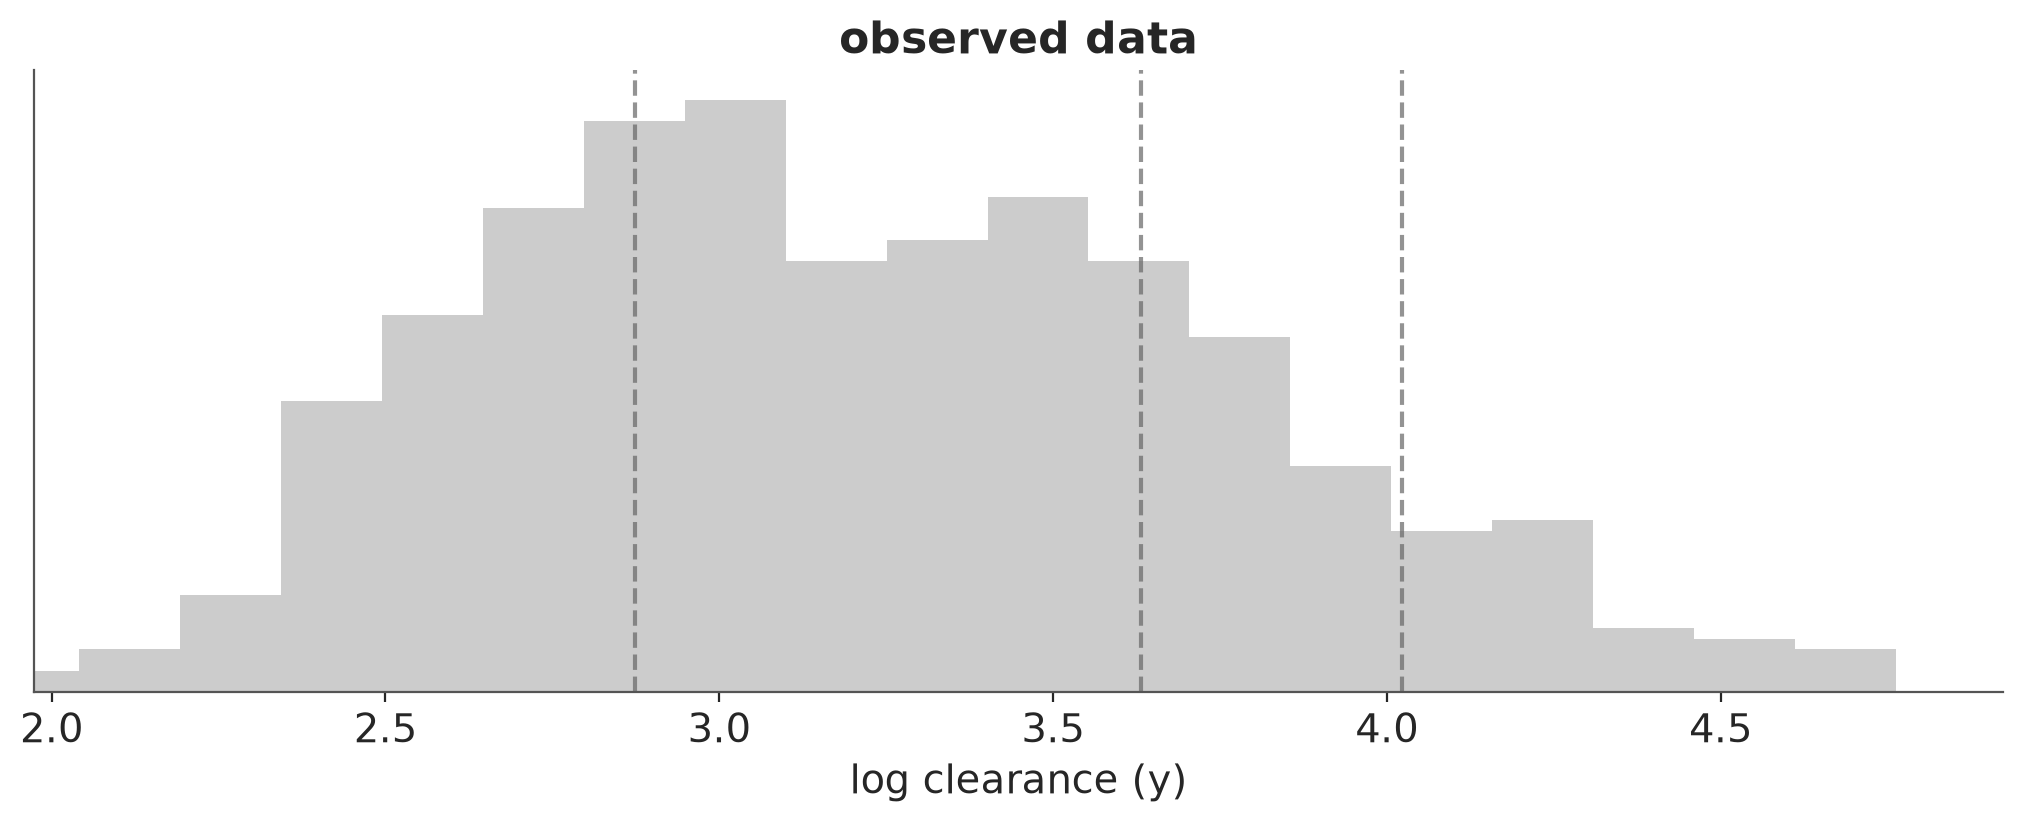

In [3]:
# histogram of the simulated data (verify multimodality)
_, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    y,
    bins=20,
    color="0.8",
    edgecolor=None,
)
for cl in log_clearances:
    ax.axvline(cl, color="0.4", linestyle="--", alpha=0.7)
ax.set(title="observed data", xlabel="log clearance (y)", xlim=xlim, yticks=[]);


### Covariate relationships (3D visualization)

In 3D space $(W_i, A_i, y_i)$, the data lies along three parallel response surfaces corresponding to the three metabolic groups. Each surface has a positive slope in weight ($\eta = 0.75$) and a small negative slope in age ($\alpha = -0.10$). We visualize the simulated cohort alongside the three mean phenotype planes:

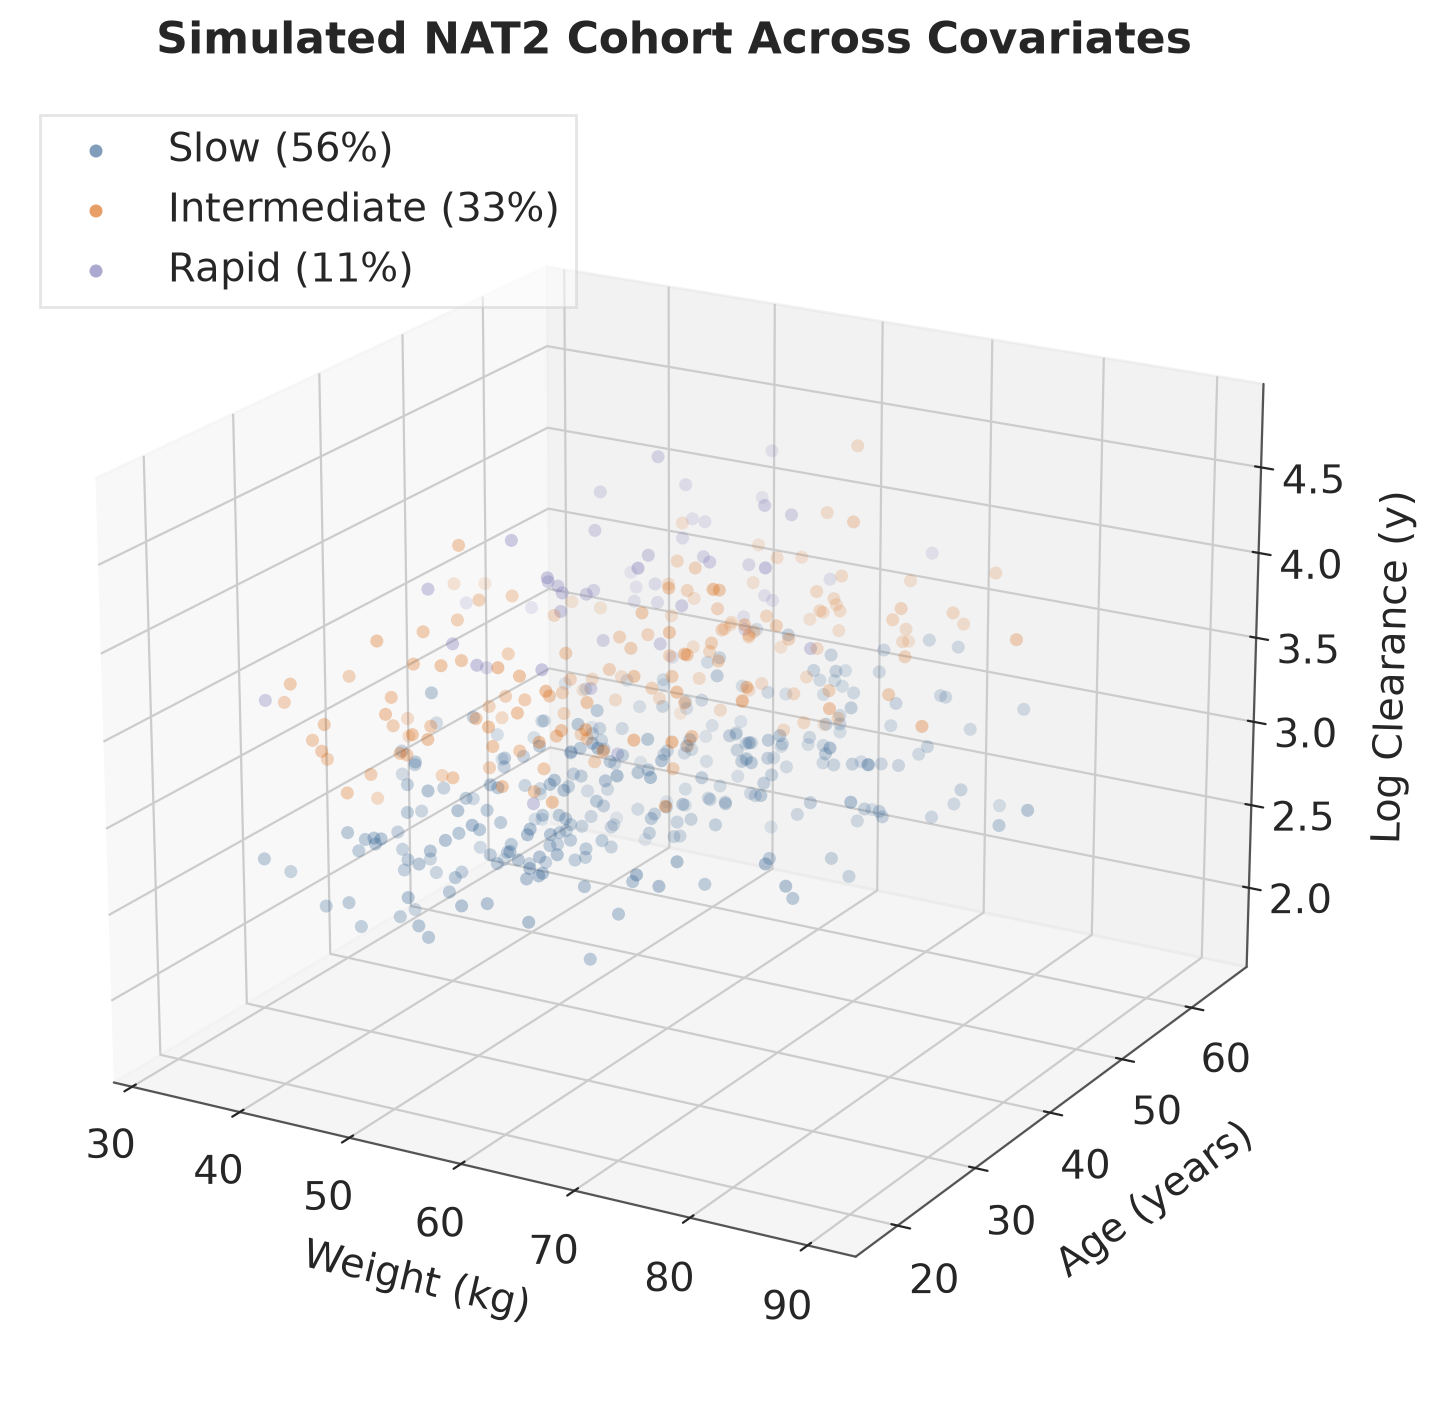

In [4]:
# 3D visualization of the cohort across covariates and latent phenotypes
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

colors = ["#2b5c8f", "#d95f02", "#7570b3"]
labels = ["Slow (56%)", "Intermediate (33%)", "Rapid (11%)"]



for g in range(3):
    mask = (genotype == g)
    ax.scatter(
        weight[mask],
        age[mask],
        y[mask],
        c=colors[g],
        label=labels[g],
        alpha=0.6,
        s=22,
        edgecolors="none",
    )

ax.set_xlabel("Weight (kg)", labelpad=10)
ax.set_ylabel("Age (years)", labelpad=10)
ax.set_zlabel("Log Clearance (y)", labelpad=10)
ax.set_title("Simulated NAT2 Cohort Across Covariates", pad=15)
ax.view_init(elev=20, azim=-60)
ax.legend(loc="upper left", frameon=True)
plt.show()


## PyMC model (misspecified unimodal likelihood)

We place standard normal priors on the regression coefficients $\beta_0, \beta_1, \beta_2$ and define
$y_i \mid \beta \sim \mathcal{N}(\beta_0 + \beta_1\,\ell_i + \beta_2\,c_i,\ \sigma^2)$ with known within-group noise $\sigma = 0.30$.

In [5]:
with pm.Model() as model:
    # Intentionally bad prior to demonstrate gradient flow and particle splitting
    beta0 = pm.Normal("beta0", mu=2, sigma=1) 
    beta1 = pm.Normal("beta1", mu=0.75, sigma=1)
    beta2 = pm.Normal("beta2", mu=0.5, sigma=1)

    mu = beta0 + beta1 * log_weight + beta2 * centred_age
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)


In [6]:
# Run standard Bayesian MCMC baseline for comparison
with model:
    idata_bayes = pm.sample(
        draws=1000,
        tune=1000,
        random_seed=SEED,
        progressbar=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, beta2]


/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


### Run the sampler

Sampling uses a particle-discretized Wasserstein gradient flow on $N = 500$ observations. We set `tune=0` so every simulation step is retained for the trajectory plot (`n_steps` maps to the `draw` coordinate).

We use 60 particles, 800 steps, `step_size=None` (FUSE adaptive schedule; floor `r_eps=1e-5`), `kgd_interval=10`, and learning rate $\lambda_n = 1$ (default). Below we inspect the DataTree output, plot KGD and FUSE diagnostics, particle trajectories, and a posterior predictive check in $y$-space.

In [7]:
dt = pro.sample_pro(
    model=model,
    n_particles=64,
    n_steps=4000,
    step_size=None,
    r_eps=1e-5,
    tune=0,
    kgd_interval=5,
    random_seed=SEED,
)


## ArviZ DataTree output

`sample_pro` returns an ArviZ [DataTree](https://python.arviz.org/projects/base/en/latest/tutorial/WorkingWithDataTree.html). Coordinates: `draw` is the retained index, `step` is the simulation step number, and `chain` is the particle index. Particles are ensemble trajectories, not independent MCMC chains, so diagnostics such as `az.rhat` and `az.ess` are not meaningful here.

Groups:
- `posterior`: particle clouds over retained steps (`sample_dims=["draw", "chain"]`).
- `mixture_log_predictive`: analytic log marginal $\log p_{\hat Q}(y_i)$ at observed data (dims `draw`, obs — no `chain`).
- `sample_stats`: flow diagnostics. `mixture_log_predictive_total` sums mixture log predictive over observations (broadcast to `chain` for ArviZ layout). `mean_log_score` averages per-particle log-score sums, which is a different quantity. With FUSE (`step_size=None`), it stores `fuse_step_size`, `fuse_gradient_energy`, and `fuse_half_step_distance_sq`. With `kgd_interval`, it also records `kgd`.
- `posterior_predictive`: mixture PPC draws from `sample_posterior_predictive_pro` (added in a later cell). Shape `(draw, …)` with `sample_dims=["draw"]` — one row per retained step, aligned with `posterior.draw` / `step`, no `chain` dim.

In [8]:
dt


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (draw: 4000, chain: 64)
│       Coordinates:
│         * draw     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│           step     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│         * chain    (chain) int64 512B 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
│       Data variables:
│           beta0    (draw, chain) float64 2MB 2.262 2.038 1.415 ... 3.547 2.813 3.078
│           beta1    (draw, chain) float64 2MB 1.873 2.136 1.792 ... 0.7494 0.5863
│           beta2    (draw, chain) float64 2MB 0.5429 1.147 -1.322 ... -0.06861 -0.3001
│       Attributes:
│           created_at:                 2026-10-05T14:07:12.291714+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /observed_data
│       Dimensions:  (y_dim_0: 500)
│       Coordinates:
│         * y_dim_0  (y_dim_0) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│       Data variables:
│           y        (y_dim_0) float64 4kB 2.389 3.486 3.427 3.028 ... 3.018 2.548 2.442
│       Attributes:
│           created_at:                 2026-10-05T14:07:12.436491+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /log_likelihood
│       Dimensions:  (draw: 4000, chain: 64, y_dim_0: 500)
│       Coordinates:
│         * draw     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│           step     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│         * chain    (chain) int64 512B 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
│         * y_dim_0  (y_dim_0) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│       Data variables:
│           y        (draw, chain, y_dim_0) float64 1GB -6.213 -31.4 ... -1.699 0.1496
│       Attributes:
│           created_at:                 2026-10-05T14:07:12.291714+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /sample_stats
│       Dimensions:                       (draw: 4000, chain: 64)
│       Coordinates:
│         * draw                          (draw) int64 32kB 0 1 2 3 ... 3997 3998 3999
│           step                          (draw) int64 32kB 0 1 2 3 ... 3997 3998 3999
│         * chain                         (chain) int64 512B 0 1 2 3 4 ... 60 61 62 63
│       Data variables:
│           particle_spread               (draw, chain) float64 2MB 1.07 1.07 ... 0.4319
│           learning_rate                 (draw, chain) float64 2MB 1.0 1.0 ... 1.0 1.0
│           beta0_spread                  (draw, chain) float64 2MB 1.005 ... 0.426
│           beta1_spread                  (draw, chain) float64 2MB 1.098 ... 0.7358
│           beta2_spread                  (draw, chain) float64 2MB 1.106 ... 0.1338
│           mean_log_score                (draw, chain) float64 2MB -1.472e+04 ... -1...
│           se_log_score                  (draw, chain) float64 2MB 1.49e+03 ... 146.2
│           fuse_gradient_energy          (draw, chain) float64 2MB 7.398e+05 ... 4.8...
│           fuse_half_step_distance_sq    (draw, chain) float64 2MB 0.0 0.0 ... 4.971
│           fuse_step_size                (draw, chain) float64 2MB 1e-05 ... 0.0002845
│           kgd                           (draw, chain) float64 2MB 227.6 227.6 ... nan
│           mixture_log_predictive_total  (draw, chain) float64 2MB -914.2 ... -365.4
│      

## Kernel Gradient Discrepancy (KGD) diagnostic

When `kgd_interval` is specified, `sample_pro` records the V-statistic in `sample_stats["kgd"]`. We plot the raw metric to check convergence.

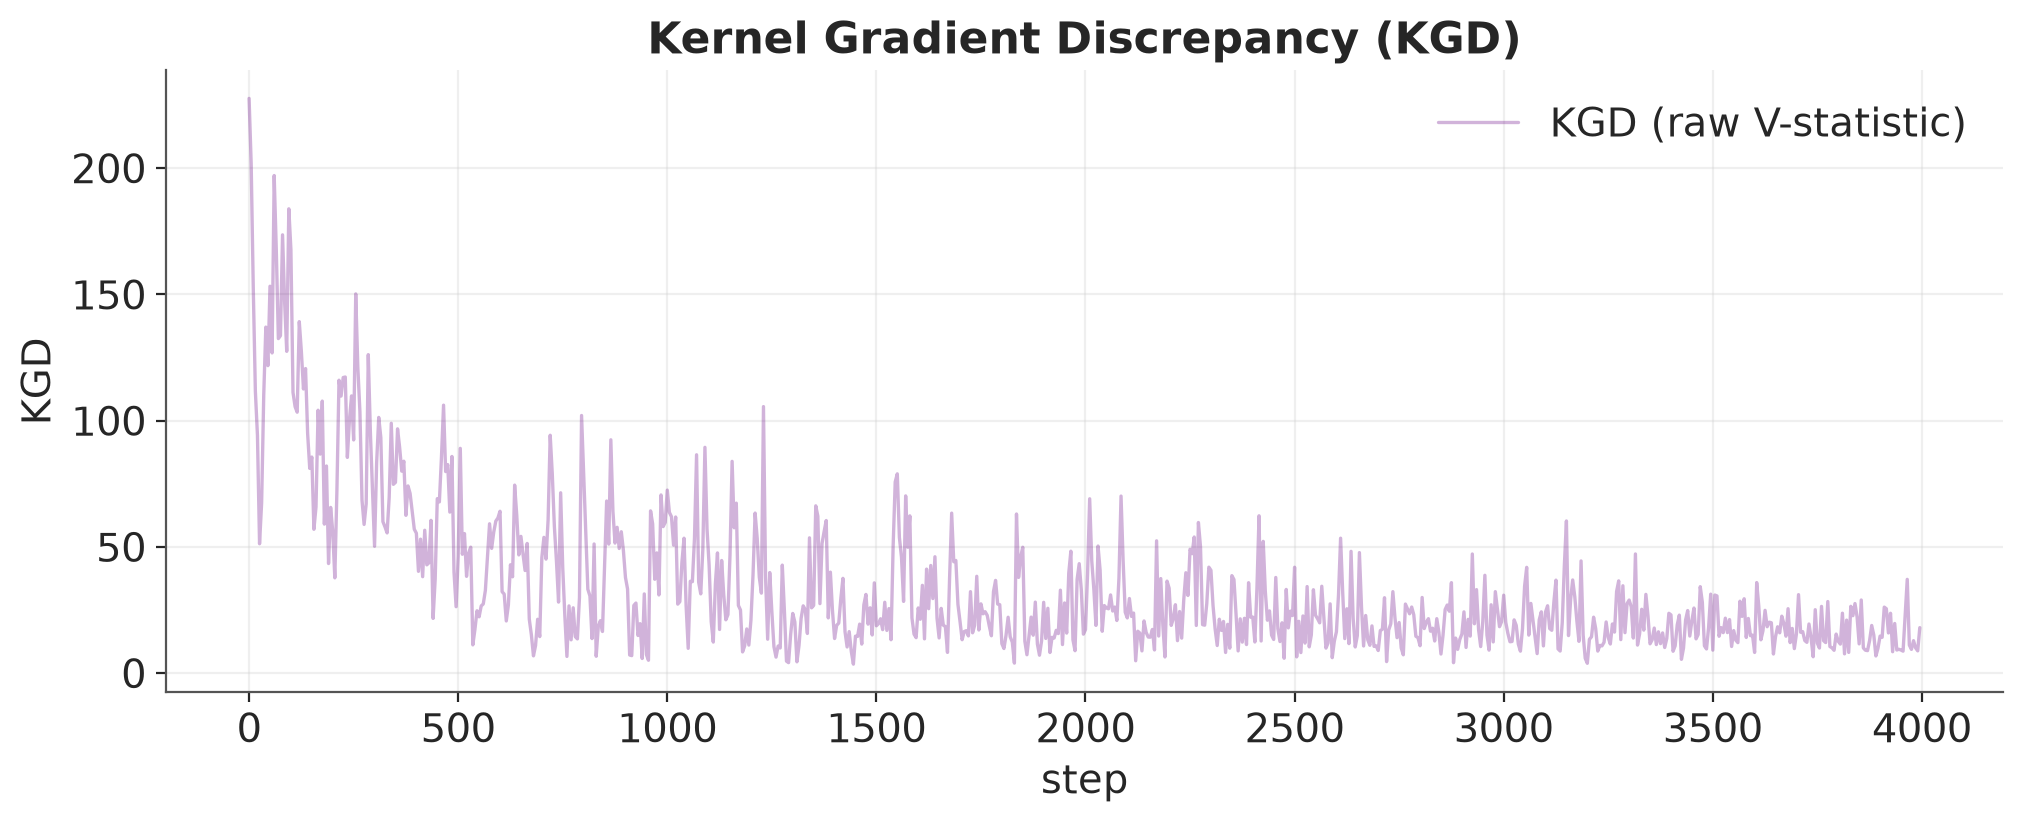

In [16]:
kgd_series = dt.sample_stats["kgd"].isel(chain=0)
kgd_steps = kgd_series.step.values[np.isfinite(kgd_series.values)]
kgd_raw = kgd_series.values[np.isfinite(kgd_series.values)]



_, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    kgd_steps,
    kgd_raw,
    color="C3",
    alpha=0.35,
    lw=1.2,
    label="KGD (raw V-statistic)",
)
ax.set(
    title="Kernel Gradient Discrepancy (KGD)",
    xlabel="step",
    ylabel="KGD",
    #yscale="log",
)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3);


## FUSE schedule diagnostics

When `step_size=None`, FUSE records per-retained-step quantities in `sample_stats`:

- `fuse_step_size`: adaptive step size used that step
- `fuse_gradient_energy`: incremental gradient energy (mean squared raw drift over particles)
- `fuse_half_step_distance_sq`: squared empirical distance between the fixed reference half-step and the current half-step.

These are step-only traces (identical across `chain`); we plot against simulation `step`.

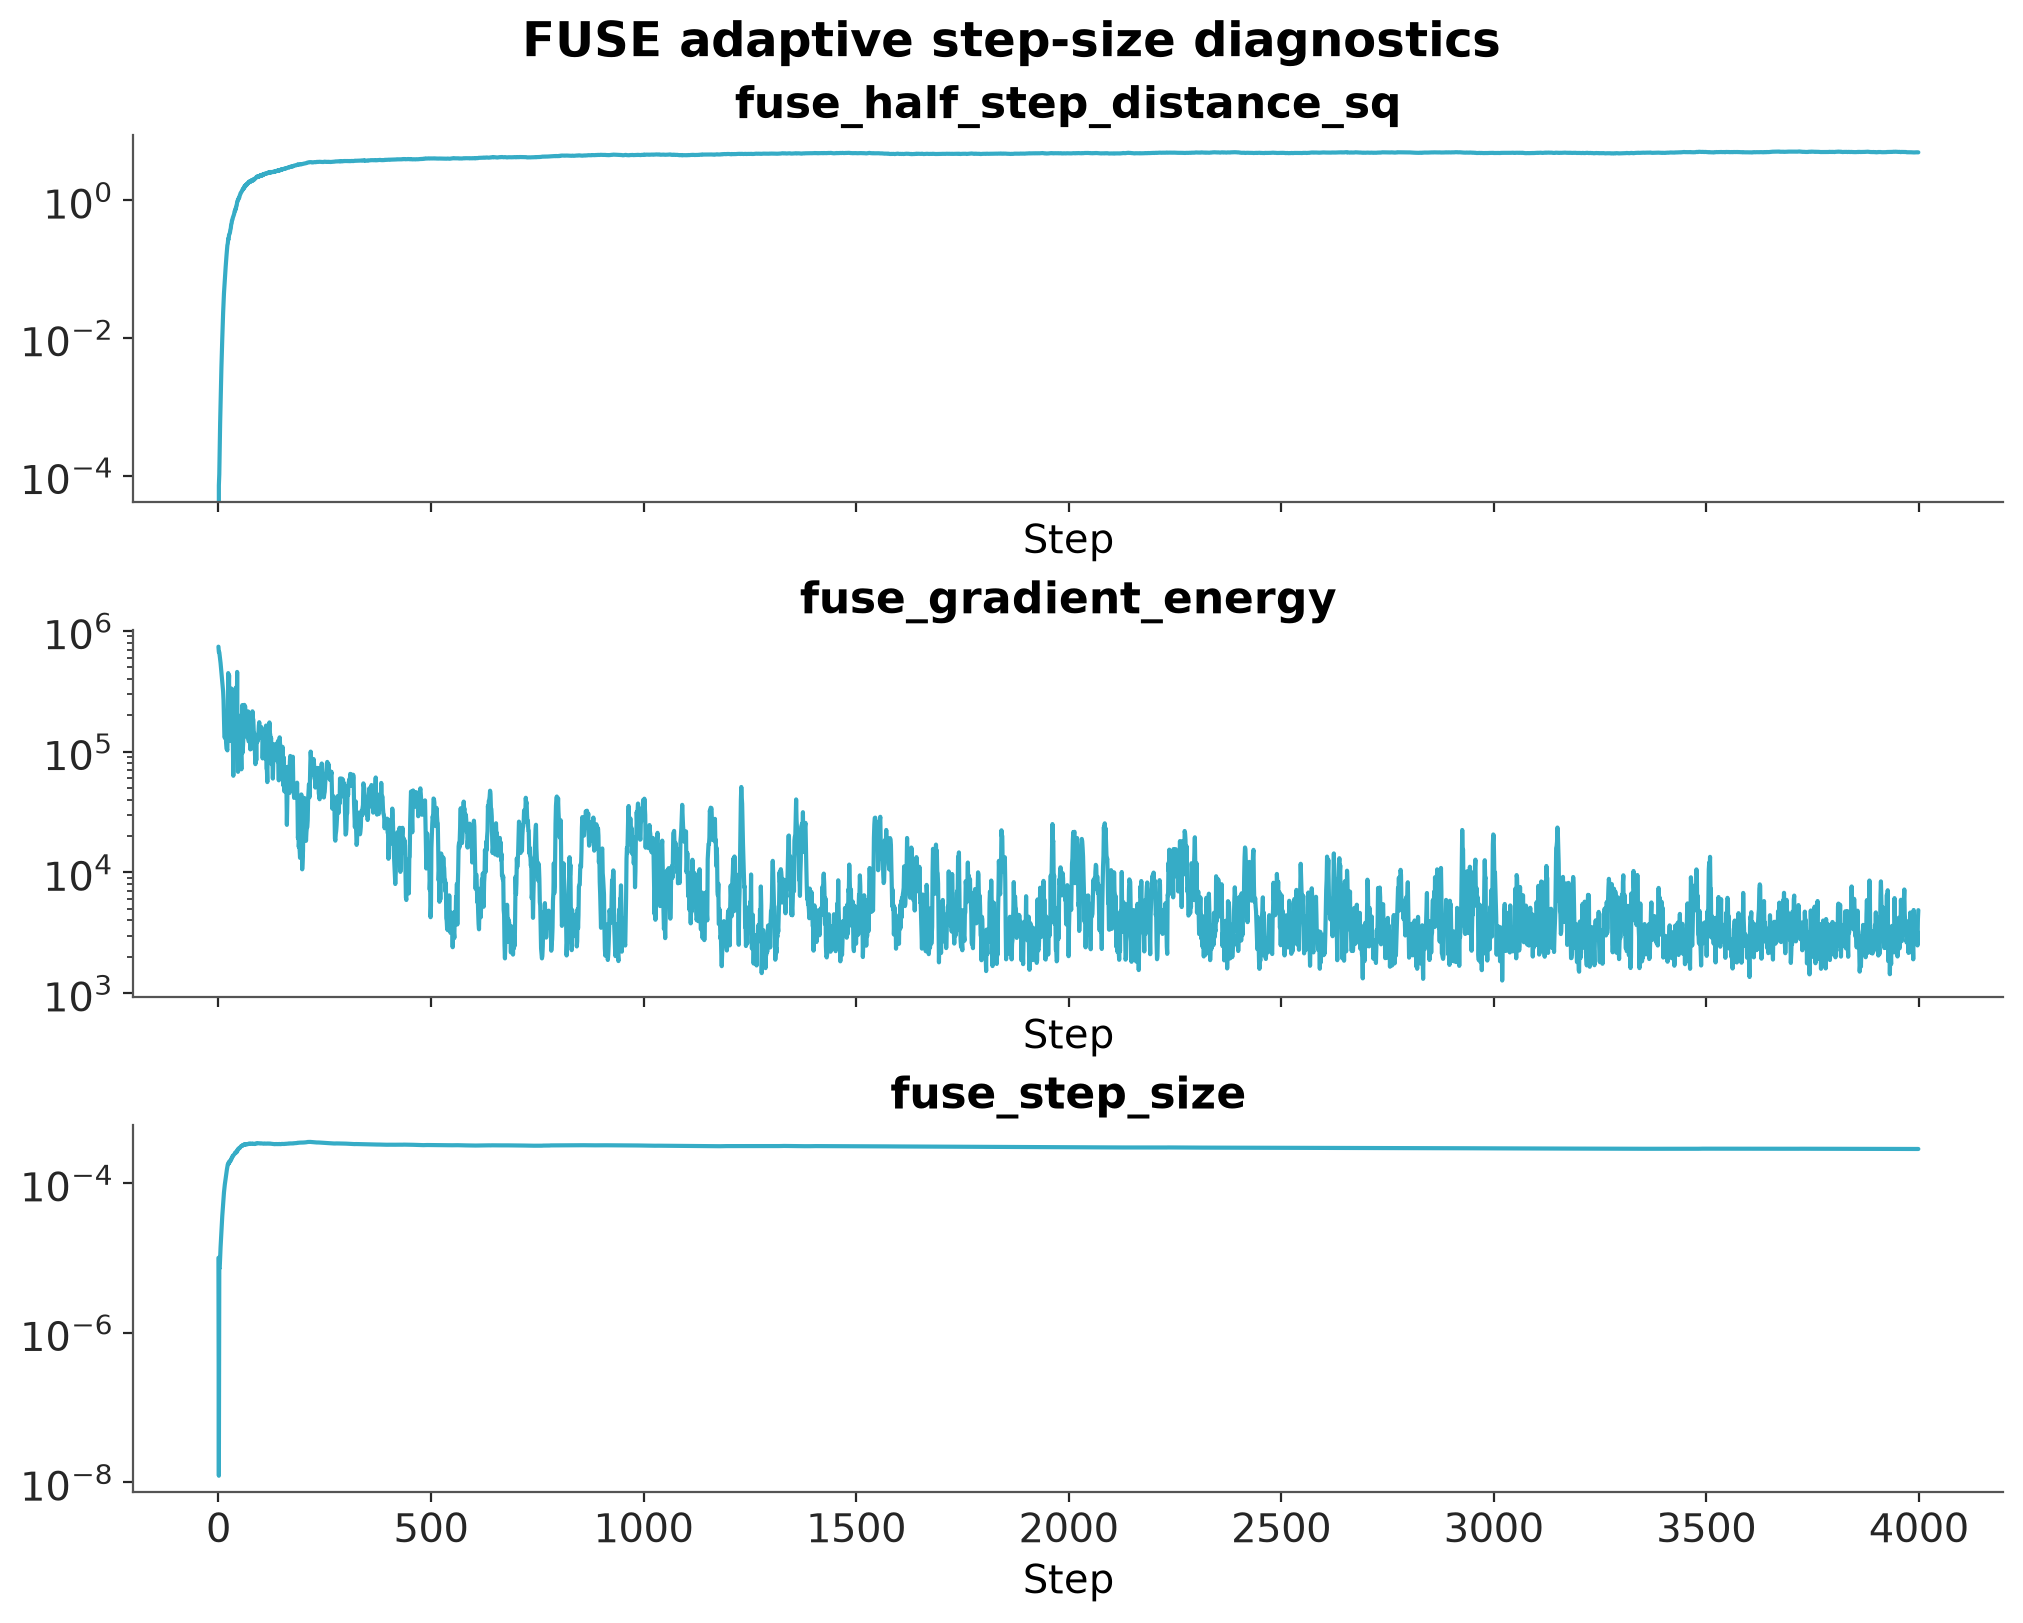

In [17]:
to_plot_dt = dt.sel(chain=[0])
pc = az.plot_trace(
    to_plot_dt,
    var_names=[
        "fuse_half_step_distance_sq",
        "fuse_gradient_energy",
        "fuse_step_size",
    ],
    group="sample_stats",
    visuals={"trace": {"xname": "step"}},
    col_wrap=1,
    figure_kwargs={"figsize": (10, 8)},
)
pc.facet_map("set_yscale", scale="log")
pc.add_title("FUSE adaptive step-size diagnostics")


## Particle trajectories

Each line traces one particle $\theta_t^{(j)} = (\beta_{0,t}^{(j)}, \beta_{1,t}^{(j)}, \beta_{2,t}^{(j)})$. Under misspecification, baseline intercept trajectories $\beta_0$ split across all three true phenotype clearance levels ($\log 17.7 \approx 2.87$, $\log 37.8 \approx 3.63$, $\log 55.9 \approx 4.02$). The allometric exponent $\beta_1$ and age slope $\beta_2$ contract around their true values ($0.75$ and $-0.10$).

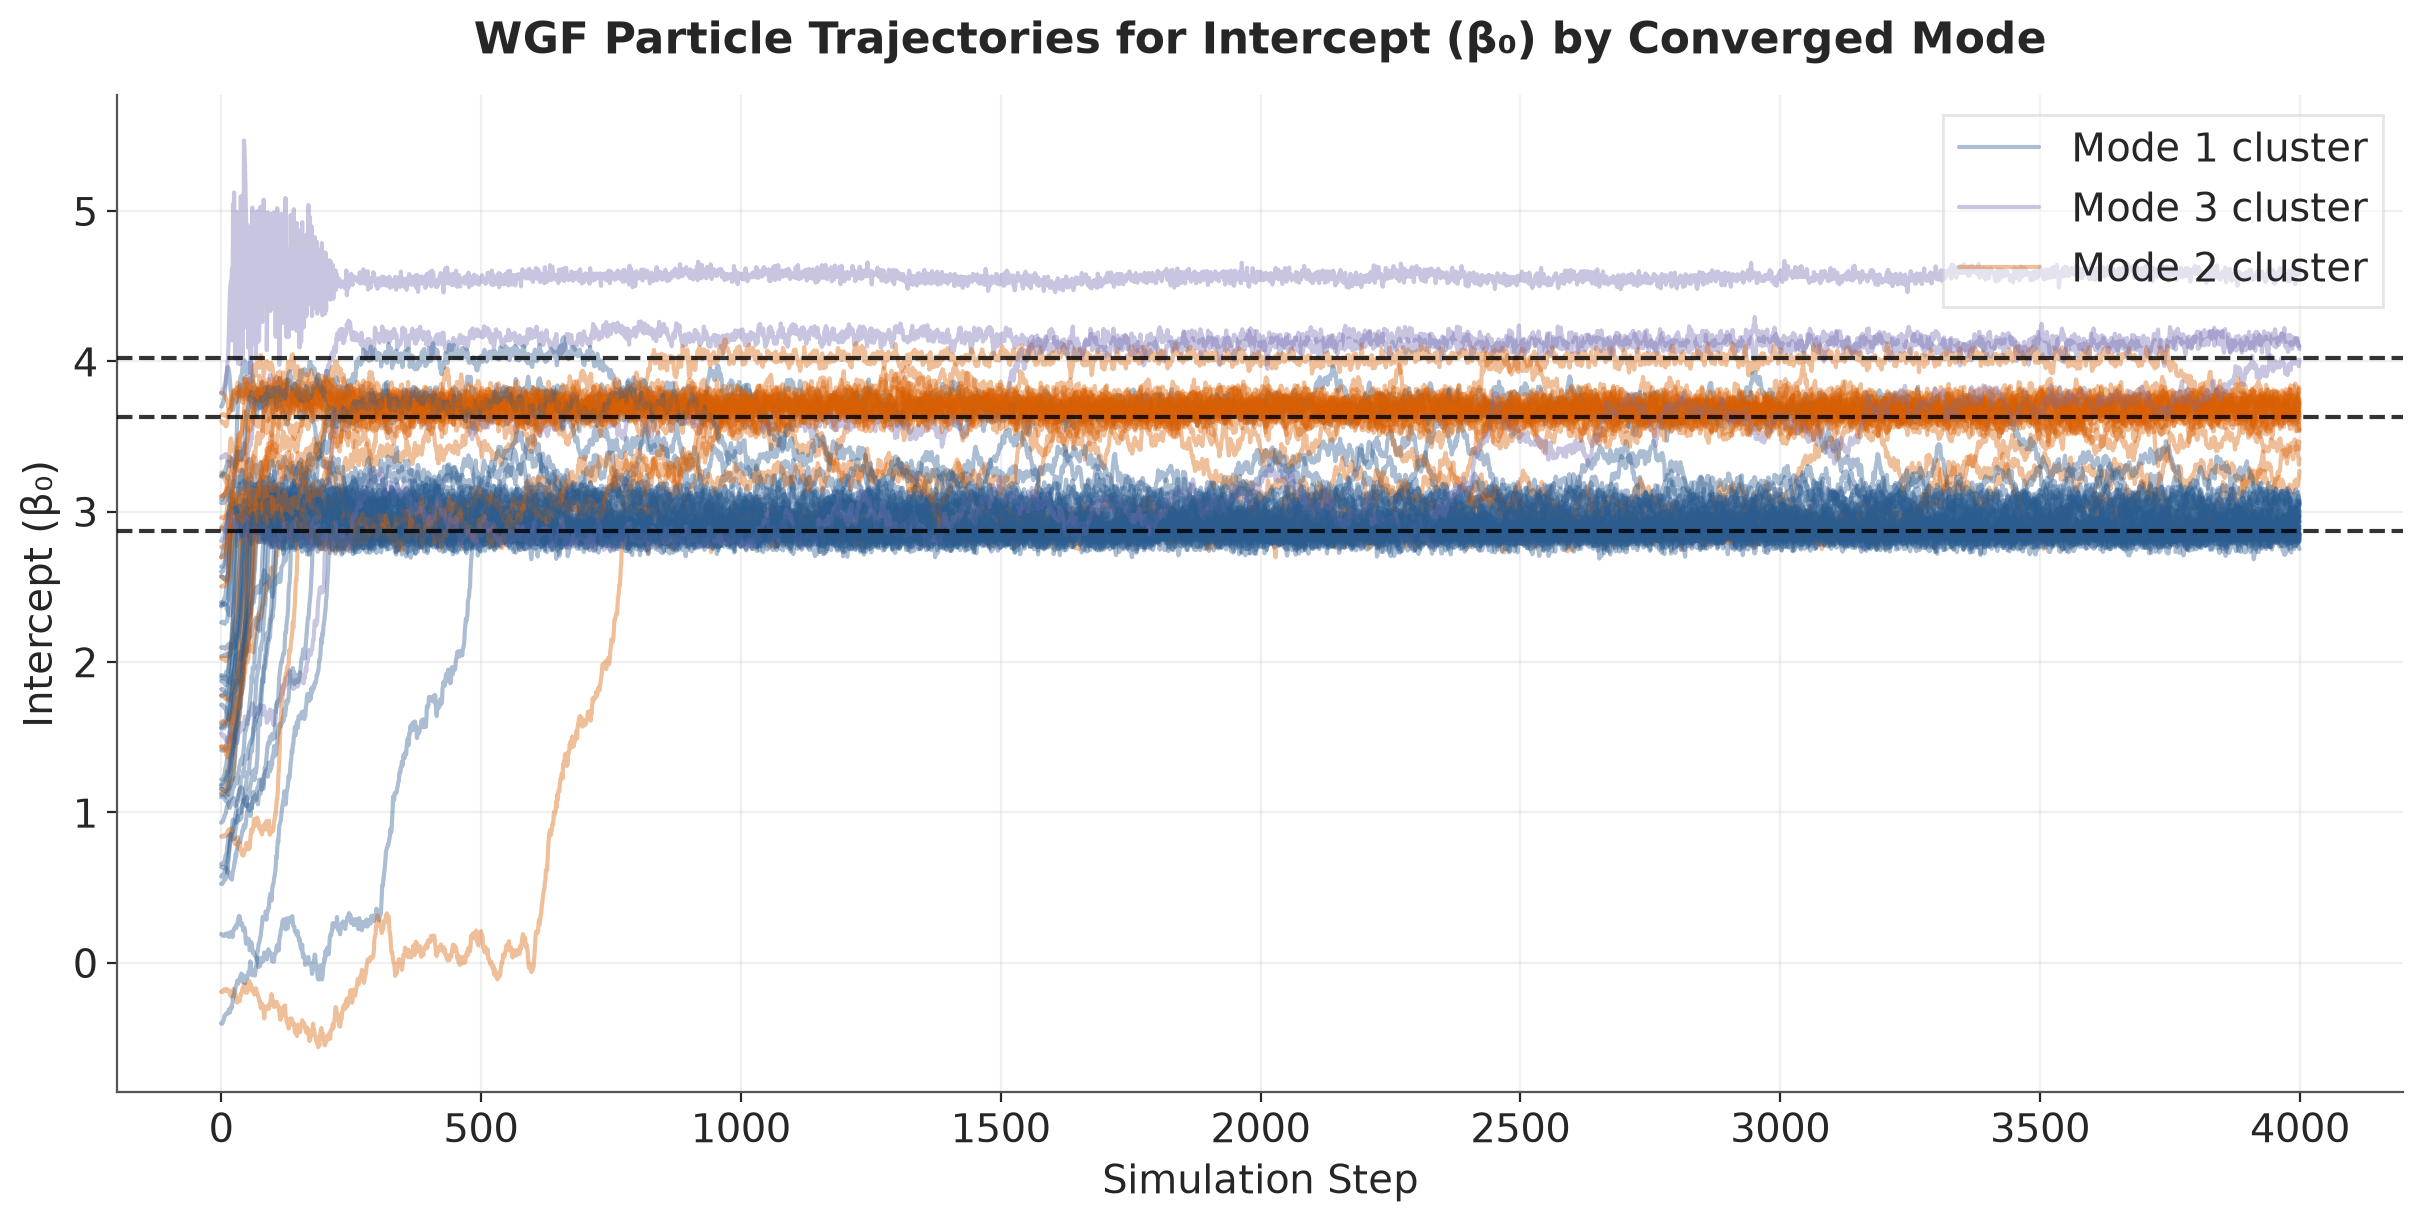

In [18]:
# Extract beta0 trajectories and step numbers from the DataTree
# beta0_traces shape is (800 steps, 60 particles)
beta0_traces = dt.posterior["beta0"].values 
steps = dt.posterior.step.values

fig, ax = plt.subplots(figsize=(12, 6))

# Define colors matching the 3D covariate plot for consistency
mode_colors = ["#2b5c8f", "#d95f02", "#7570b3"]
labels_added = set()

# Plot each particle's trajectory
for i in range(beta0_traces.shape[1]):
    particle_path = beta0_traces[:, i]
    final_val = particle_path[-1]
    
    # Determine which true clearance mode this particle is closest to at the end
    closest_mode = np.argmin(np.abs(final_val - log_clearances))
    color = mode_colors[closest_mode]
    
    # Add label only once per mode for the legend
    label = f"Mode {closest_mode + 1} cluster" if closest_mode not in labels_added else None
    labels_added.add(closest_mode)
    
    ax.plot(steps, particle_path, color=color, alpha=0.4, lw=1.5, label=label)

# Add horizontal lines for the true latent log clearance values
for cl in log_clearances:
    ax.axhline(cl, color="black", linestyle="--", alpha=0.8, zorder=10)

ax.set_title("WGF Particle Trajectories for Intercept (β₀) by Converged Mode", pad=15)
ax.set_xlabel("Simulation Step")
ax.set_ylabel("Intercept (β₀)")
ax.legend(loc="upper right", frameon=True)
ax.grid(True, alpha=0.3)

plt.show()

## Posterior predictive check

Theorem 1 is about the marginal PrO predictive $P_Q = \int P_\theta\, dQ(\theta)$ in observation space $\mathcal{Y}$.

`sample_posterior_predictive_pro` calls `pm.sample_posterior_predictive` on the full retained cloud (`sample_dims=["draw", "chain"]`), then remixes the per-particle grid into draw-aligned mixture PPC draws (`posterior_predictive` with `sample_dims=["draw"]`). `az.plot_ppc_dist` below overlays those mixture draws with the observed data.

In [19]:
ppc_dt = pro.sample_posterior_predictive_pro(
    dt,
    model=model,
    random_seed=SEED,
)


Sampling: [y]


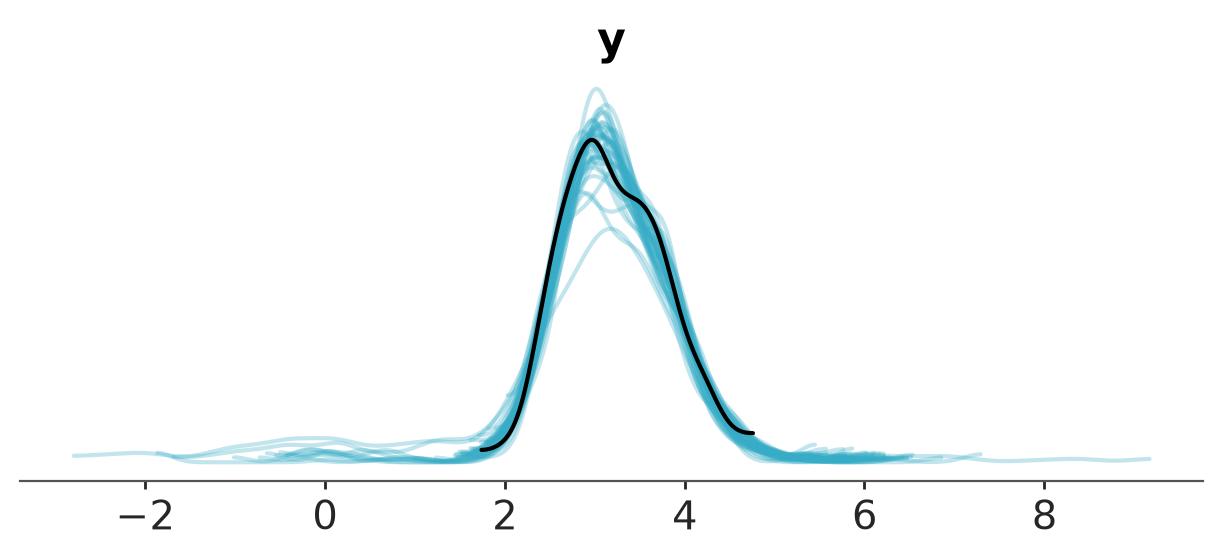

In [20]:
az.plot_ppc_dist(ppc_dt, num_samples=40);


### Parameter inferences: Bayes vs. PrO

Comparing the posterior distribution of $\beta_0$ under Bayes with the converged particle cloud under PrO shows the difference clearly: Bayes collapses to a compromise mean ($\beta_0 \approx 3.25$), whereas PrO places particles across all three true modes.

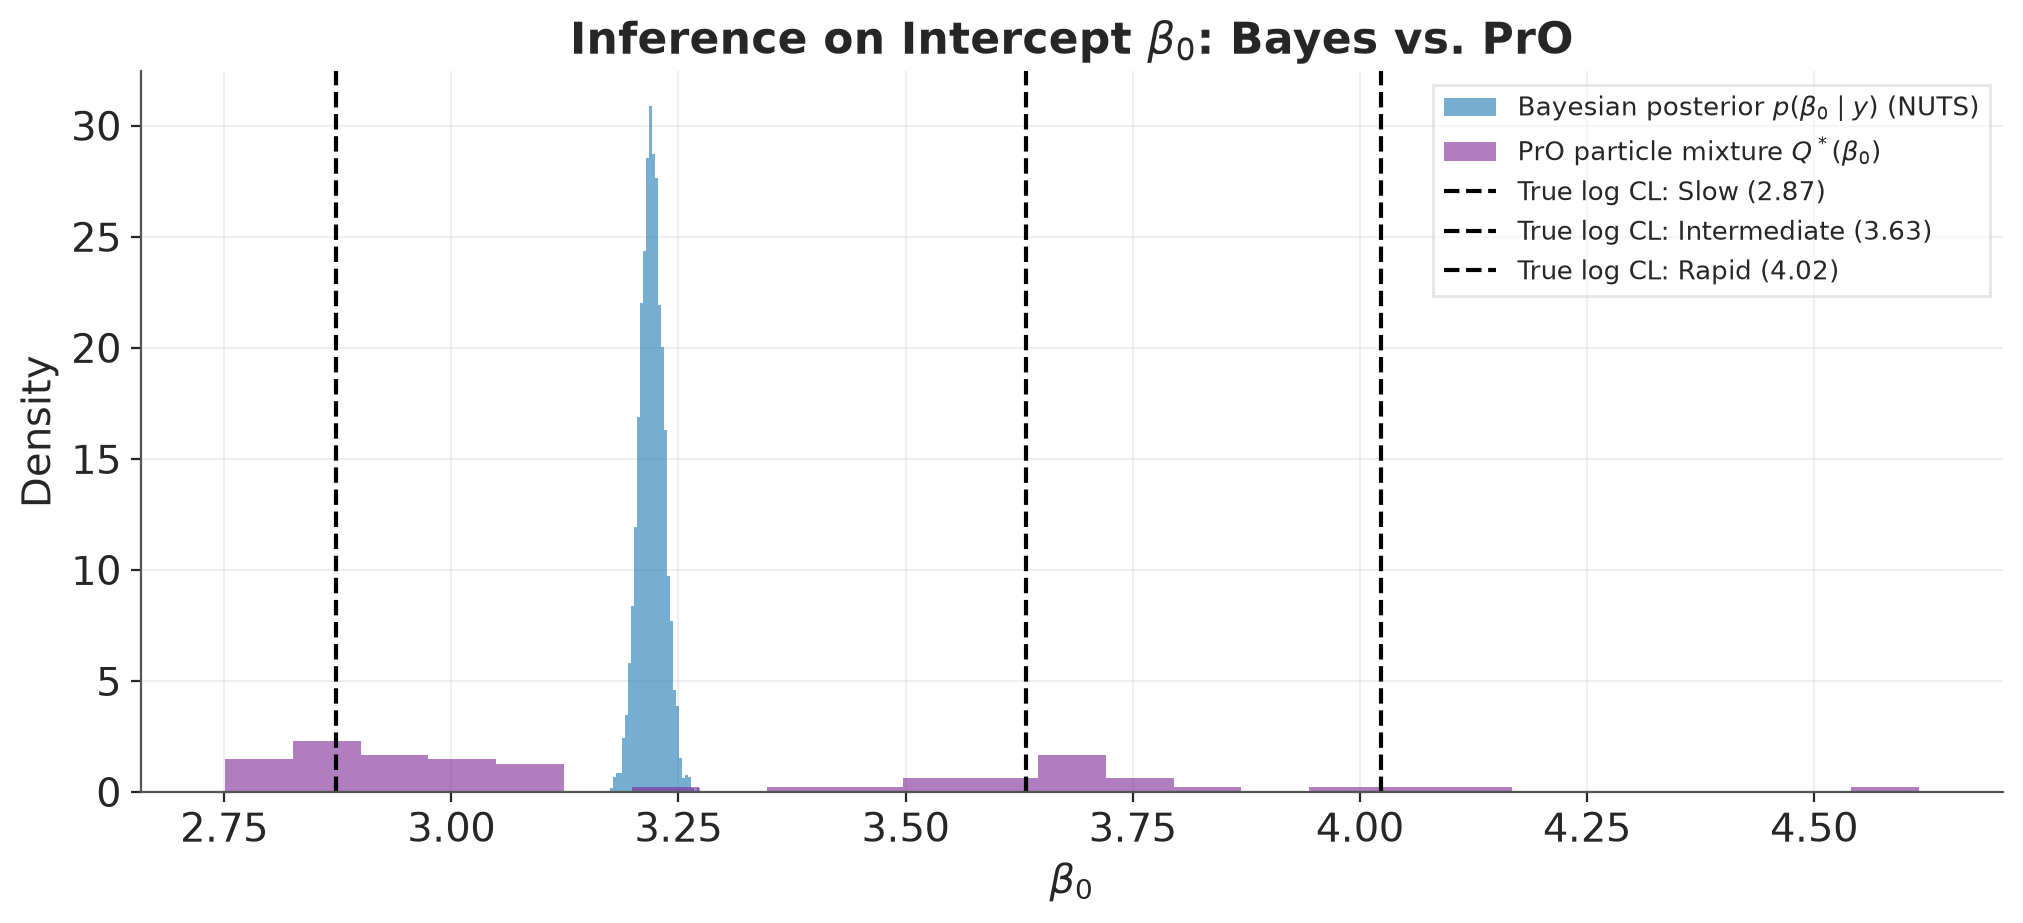

In [21]:
b0_bayes = idata_bayes.posterior["beta0"].values.ravel()
b0_final = dt.posterior["beta0"].isel(draw=-1).values

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(b0_bayes, bins=30, density=True, color="#1f77b4", alpha=0.6, label=r"Bayesian posterior $p(\beta_0 \mid y)$ (NUTS)")
ax.hist(b0_final, bins=25, density=True, color="C3", alpha=0.6, label=r"PrO particle mixture $Q^*(\beta_0)$")

for cl_val, name in zip(log_clearances, ["Slow (2.87)", "Intermediate (3.63)", "Rapid (4.02)"]):
    ax.axvline(cl_val, color="black", ls="--", lw=1.5, label=f"True log CL: {name}")

ax.set(
    title=r"Inference on Intercept $\beta_0$: Bayes vs. PrO",
    xlabel=r"$\beta_0$",
    ylabel="Density",
)
ax.legend(frameon=True, loc="upper right", fontsize=9.5)
ax.grid(True, alpha=0.3)
plt.show()


### Conditional prediction for a reference patient

For a reference patient of standard weight (55 kg, $\ell = 0$) and age (40 years, $c = 0$), the true conditional law is a three-component Gaussian mixture:
$$y \mid \ell=0, c=0 \sim 0.56\,\mathcal{N}(2.87, 0.30^2) + 0.33\,\mathcal{N}(3.63, 0.30^2) + 0.11\,\mathcal{N}(4.02, 0.30^2).$$

We compare this analytical truth against the PrO mixture predictive density and the Bayesian predictive density.

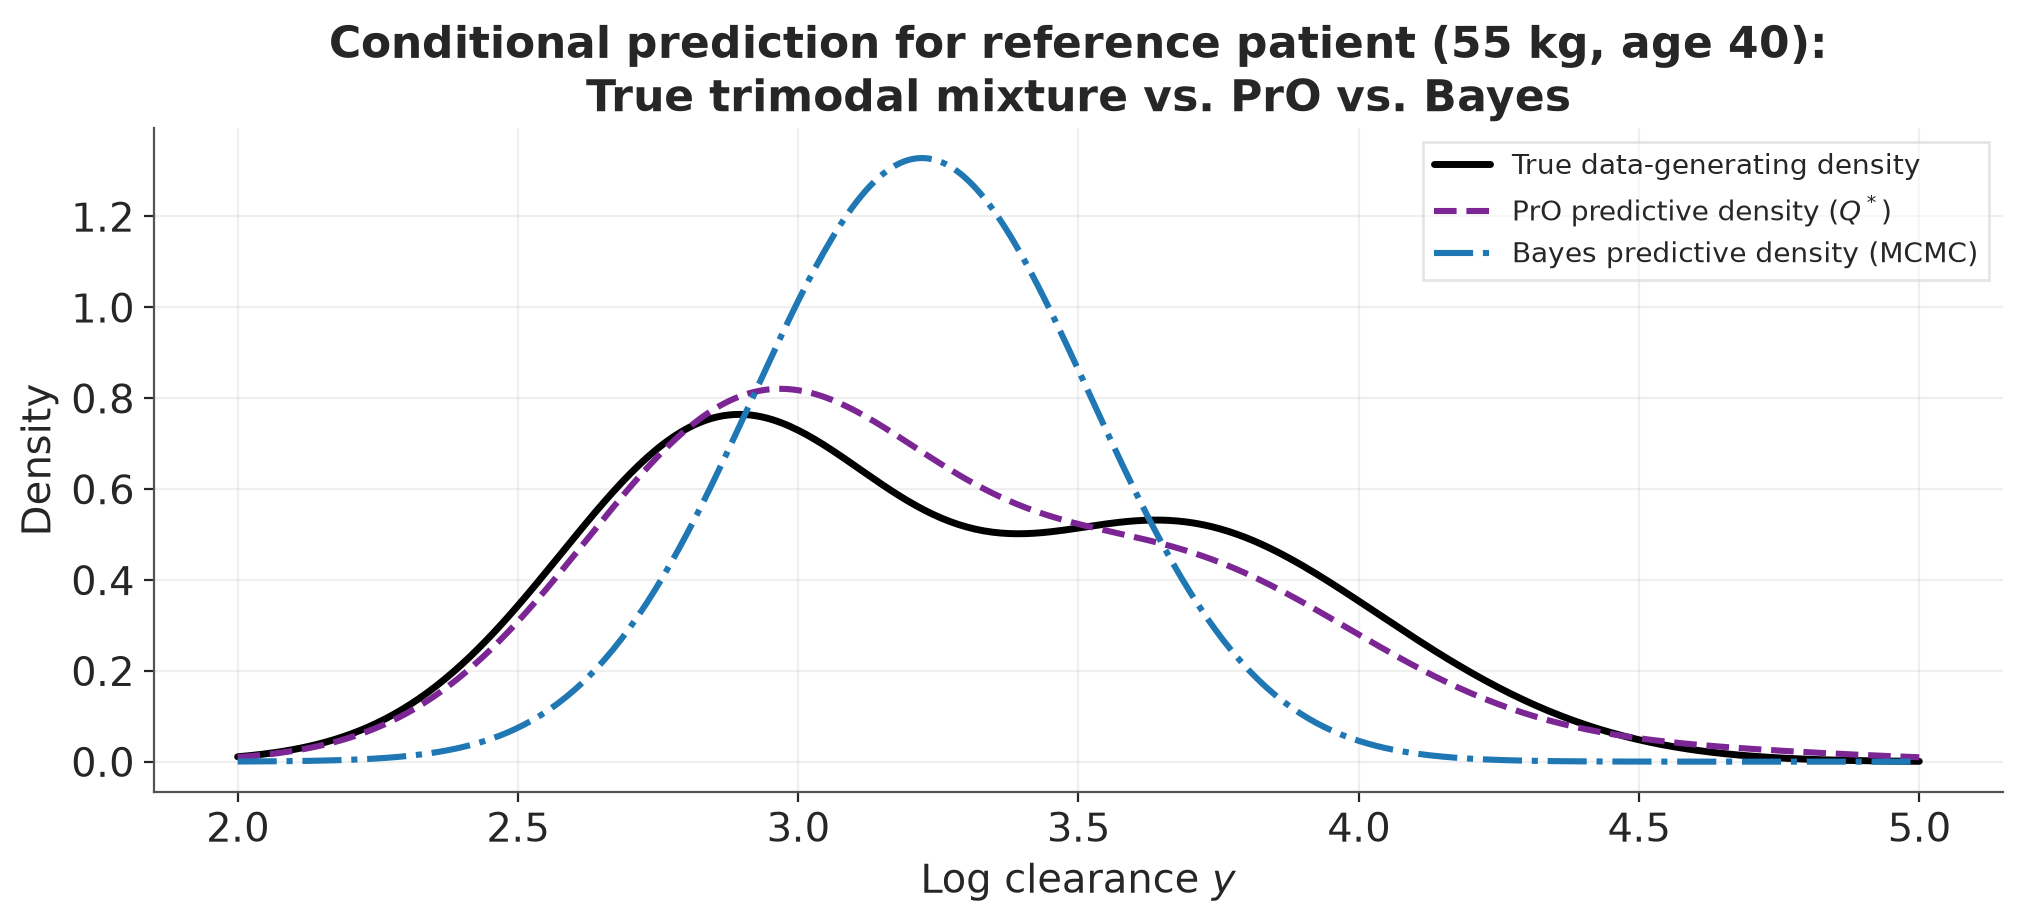

In [22]:
y_grid = np.linspace(2.0, 5.0, 400)

# True mixture density at ell=0, c=0
true_dens = np.zeros_like(y_grid)
for p_g, log_cl_g in zip(freq, log_clearances):
    true_dens += p_g * (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((y_grid - log_cl_g) / sigma) ** 2)

# PrO predicted density at ell=0, c=0: mixture over final particles
pro_dens = np.zeros_like(y_grid)
for b0 in b0_final:
    pro_dens += (1.0 / len(b0_final)) * (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((y_grid - b0) / sigma) ** 2)

# Bayes predicted density at ell=0, c=0: average over MCMC draws
bayes_dens = np.zeros_like(y_grid)
for b0 in b0_bayes[:500]:
    bayes_dens += (1.0 / 500) * (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((y_grid - b0) / sigma) ** 2)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(y_grid, true_dens, color="black", lw=2.5, label="True data-generating density")
ax.plot(y_grid, pro_dens, color="C3", lw=2.2, ls="--", label=r"PrO predictive density ($Q^*$)")
ax.plot(y_grid, bayes_dens, color="#1f77b4", lw=2.2, ls="-.", label="Bayes predictive density (MCMC)")

ax.set(
    title="Conditional prediction for reference patient (55 kg, age 40):\nTrue trimodal mixture vs. PrO vs. Bayes",
    xlabel=r"Log clearance $y$",
    ylabel="Density",
)
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()
